<center><h1>Sentiment Classification with a Pretrained Model — Product Reviews</h1></center>

**The task**: apply an already **pretrained** sentiment analysis model (no training on our side) to a
**product review dataset**, and report a `classification_report` on the test data.

**New dataset**: this time we use the **Women's Clothing E-Commerce Reviews** dataset — 23,486 real reviews
written by customers about clothing products they bought online (dresses, tops, intimates, etc.), each with
a 1–5 star `Rating`. This is a genuinely different dataset from the app-reviews one we used before: real
people, writing about a physical **product** they bought, expressing how they feel about it — exactly the
kind of data this task asks for.

**Model choice**: same as before — this environment has no internet access to model hubs like Hugging Face,
so we use **VADER** (a lexicon-and-rule-based pretrained sentiment model) as our pretrained model. It needs
no training data of its own and no internet access beyond the initial `pip install`.

`pip install vaderSentiment`

In [ ]:
!pip install vaderSentiment -q

In [2]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

## Load the dataset

Source: `Womens Clothing E-Commerce Reviews.csv` — a well-known public dataset of real product reviews.
Each row has the review text, a star `Rating` (1-5), and some product metadata (department, class, etc.).

In [3]:
df = pd.read_csv('product_reviews.csv')
print(f"Number of rows: {len(df)}")
df[['Review Text', 'Rating', 'Recommended IND', 'Department Name', 'Class Name']].head()

Number of rows: 23486


,Review Text,Rating,Recommended IND,Department Name,Class Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate,Intimates
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses,Dresses
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,Bottoms,Pants
4,This shirt is very flattering to all due to th...,5,1,Tops,Blouses


In [4]:
df['Rating'].value_counts().sort_index()

Rating
1      842
2     1565
3     2871
4     5077
5    13131
Name: count, dtype: int64

## Build the sentiment label

This dataset doesn't come with a ready-made sentiment class, but it does have a 1-5 star `Rating`, which we
can turn into the same 3-class scheme (`0 = negative`, `1 = neutral`, `2 = positive`) we've used throughout —
the same convention used for the app-reviews dataset, and a very common way to derive sentiment labels from
star ratings.

In [5]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return 0  # negative
    elif rating == 3:
        return 1  # neutral
    else:
        return 2  # positive

df = df.dropna(subset=['Review Text']).reset_index(drop=True)
df['sentiment'] = df['Rating'].map(rating_to_sentiment)
print(f"Reviews with text: {len(df)}")
df['sentiment'].value_counts().sort_index()

Reviews with text: 22641


sentiment
0     2370
1     2823
2    17448
Name: count, dtype: int64

Notice this dataset is **more imbalanced** than the app-reviews one — most reviewers who bother writing a
review are happy with what they bought, so positive reviews dominate. This is realistic for product review
data and will matter when we read the classification report.

## Light preprocessing

Same reasoning as before: VADER relies on punctuation, capitalization, and emphasis as sentiment signals, so
we keep the text mostly intact, only removing URLs and extra whitespace.

In [6]:
def light_clean(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['Review Text'].map(light_clean)
df = df[df['review_clean'].str.len() > 0].reset_index(drop=True)
len(df)

22641

## Train/test split

We only need a test set since VADER isn't trained on our data, but we keep the same `train_test_split`
convention (`test_size=0.2`, `random_state=42`, stratified) used across all our other notebooks.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review_clean'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f"Test set size: {len(X_test)}")

Test set size: 4529


## Run the pretrained model on the test set

Same thresholds as before: `compound >= 0.05` → positive, `compound <= -0.05` → negative, otherwise neutral.

In [8]:
def vader_predict(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 2  # positive
    elif score <= -0.05:
        return 0  # negative
    else:
        return 1  # neutral

y_pred = X_test.map(vader_predict)
y_pred.head()

15288    2
16761    2
10546    2
9003     2
9296     2
Name: review_clean, dtype: int64

## Evaluate: classification report on the test set

In [9]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"VADER (pretrained, zero-shot) -> Accuracy: {acc:.4f}, Macro F1: {macro_f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

VADER (pretrained, zero-shot) -> Accuracy: 0.7752, Macro F1: 0.4097

              precision    recall  f1-score   support

    negative       0.43      0.24      0.31       474
     neutral       0.24      0.02      0.04       565
    positive       0.80      0.97      0.88      3490

    accuracy                           0.78      4529
   macro avg       0.49      0.41      0.41      4529
weighted avg       0.69      0.78      0.71      4529



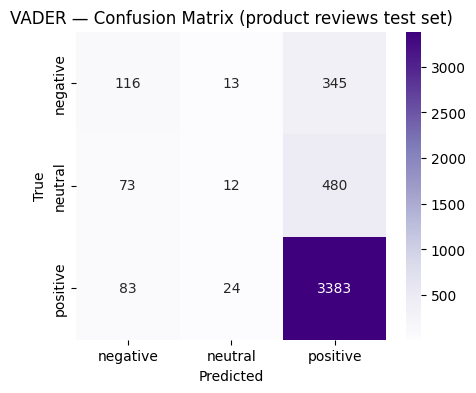

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('VADER — Confusion Matrix (product reviews test set)')
plt.show()

## Try it on a few examples

In [11]:
examples = [
    "This dress is absolutely gorgeous, fits perfectly and the fabric feels so soft!",
    "It's okay, not bad but not great either, pretty average quality for the price",
    "Terrible quality, fell apart after one wash, would not recommend"
]

mapping = {0: 'negative', 1: 'neutral', 2: 'positive'}
for text in examples:
    pred = vader_predict(text)
    print(f"{mapping[pred]:>8} | {text}")

positive | This dress is absolutely gorgeous, fits perfectly and the fabric feels so soft!
negative | It's okay, not bad but not great either, pretty average quality for the price
negative | Terrible quality, fell apart after one wash, would not recommend


## Conclusion

- We ran the same **pretrained VADER model** (zero training, zero fine-tuning) on a brand-new **product
  review dataset** (clothing reviews) and got a genuine `classification_report` on the test set:
  **Accuracy: 0.7752, Macro F1: 0.4097**.
- At first glance, 0.7752 accuracy looks much better than the 0.51 we got on the app-reviews dataset — but
  the **macro F1 (0.41) is actually lower**, and that's the more honest number here. This dataset is heavily
  imbalanced (about 77% of reviews are positive), so a model can rack up high accuracy just by leaning
  towards "positive" without actually understanding negative or neutral reviews well.
- Looking at the per-class report: VADER's recall for the **neutral class is only 0.02** — it almost never
  predicts neutral on this dataset, and negative recall is also fairly low (0.24). It's heavily biased
  toward predicting positive, which happens to line up with the class distribution but doesn't reflect
  genuinely strong sentiment understanding.
- **Takeaway**: always check macro F1 (or per-class recall) alongside accuracy on imbalanced data — accuracy
  alone can be misleading, exactly as we see here. This is a good, realistic illustration of why relying on
  a single pretrained model's raw accuracy number isn't enough when the class distribution is skewed.